In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!mkdir -p ~/.config/kaggle
!cp ~/Downloads/kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json
!python3 --version

Python 3.13.9


In [3]:
import os

COMPETITION_NAME = "playground-series-s5e11"

if not os.path.exists('./data/playground-series-s5e11.zip'):
    print("Download.")
    !kaggle competitions download -c $COMPETITION_NAME -p ./data

if not os.path.exists('./data/train.csv'):
    print("Unzip.")
    !unzip ./data/playground-series-s5e11.zip -d ./data



In [4]:
path = './data/'

train_path = path + 'train.csv'
test_path = path + 'test.csv'
submission_path = path + 'sample_submission.csv'

In [5]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
train.shape, test.shape

((593994, 13), (254569, 12))

In [7]:
train.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [9]:
TARGET = "loan_paid_back"

FEATUTRES = [col for col in train.columns if col not in ("id", TARGET)]
CATS = list(train.select_dtypes(include=["object"]).columns)

len(FEATUTRES), len(CATS)

(11, 6)

In [10]:
for df in [train, test]:
    for col in CATS:
        df[col] = df[col].astype("category")

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    593994 non-null  int64   
 1   annual_income         593994 non-null  float64 
 2   debt_to_income_ratio  593994 non-null  float64 
 3   credit_score          593994 non-null  int64   
 4   loan_amount           593994 non-null  float64 
 5   interest_rate         593994 non-null  float64 
 6   gender                593994 non-null  category
 7   marital_status        593994 non-null  category
 8   education_level       593994 non-null  category
 9   employment_status     593994 non-null  category
 10  loan_purpose          593994 non-null  category
 11  grade_subgrade        593994 non-null  category
 12  loan_paid_back        593994 non-null  float64 
dtypes: category(6), float64(5), int64(2)
memory usage: 35.1 MB


In [12]:
X = train[FEATUTRES]
y = train[TARGET]

In [13]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

N_SPLITS = 5

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [14]:
params = {
 'objective': 'binary:logistic',
 'colsample_bytree': 0.8,
 'device': "cuda",
 'early_stopping_rounds': 200,
 'enable_categorical': True,
 'eval_metric': "auc",
 'learning_rate': 0.01,
 'max_depth': 5,
 'n_estimators': 50_000,
 "n_jobs": -1,
 "random_state": 42
}

In [17]:
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))


for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATUTRES].copy()

    for df in [X_train, X_val, X_test]:
        df.loc[:, CATS] = df.loc[:, CATS].astype("category")


    model = XGBClassifier(**params)

    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=1000)
    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    fold_score = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold} AUC: {fold_score:.4f}")
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS


overall_auc = roc_auc_score(y, oof_preds)

print(f"Overall AUC: {overall_auc:.4f}")
    
    

[0]	validation_0-auc:0.77904
[1000]	validation_0-auc:0.91918
[2000]	validation_0-auc:0.92077
[3000]	validation_0-auc:0.92192
[4000]	validation_0-auc:0.92234
[5000]	validation_0-auc:0.92253
[5638]	validation_0-auc:0.92256


/home/eren/miniconda3/envs/ml-env/lib/python3.13/site-packages/xgboost/core.py:774: UserWarning: [09:48:04] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1 AUC: 0.9226
[0]	validation_0-auc:0.77880
[1000]	validation_0-auc:0.91859
[2000]	validation_0-auc:0.92009
[3000]	validation_0-auc:0.92114
[4000]	validation_0-auc:0.92164
[5000]	validation_0-auc:0.92192
[6000]	validation_0-auc:0.92198
[6437]	validation_0-auc:0.92198
Fold 2 AUC: 0.9220
[0]	validation_0-auc:0.77621
[1000]	validation_0-auc:0.91697
[2000]	validation_0-auc:0.91849
[3000]	validation_0-auc:0.91963
[4000]	validation_0-auc:0.92013
[5000]	validation_0-auc:0.92035
[6000]	validation_0-auc:0.92047
[7000]	validation_0-auc:0.92052
[7077]	validation_0-auc:0.92052
Fold 3 AUC: 0.9205
[0]	validation_0-auc:0.77563
[1000]	validation_0-auc:0.91794
[2000]	validation_0-auc:0.91954
[3000]	validation_0-auc:0.92062
[4000]	validation_0-auc:0.92105
[5000]	validation_0-auc:0.92130
[5813]	validation_0-auc:0.92134
Fold 4 AUC: 0.9213
[0]	validation_0-auc:0.77745
[1000]	validation_0-auc:0.91763
[2000]	validation_0-auc:0.91904
[3000]	validation_0-auc:0.92008
[4000]	validation_0-auc:0.92059
[5000]	v

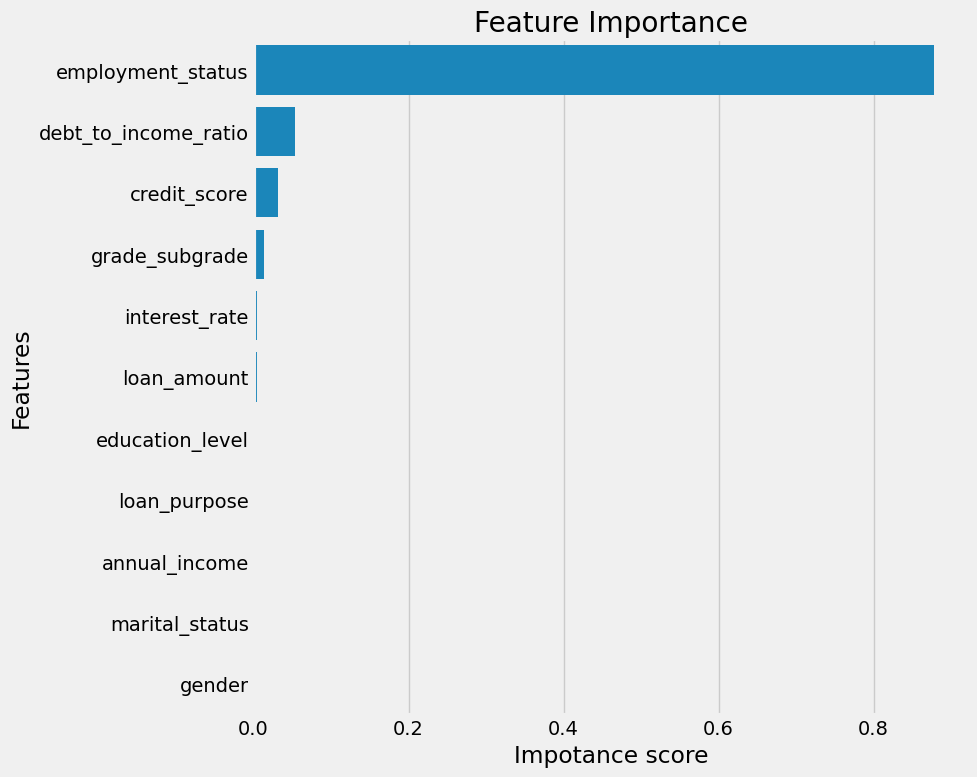

In [29]:
import seaborn as sns

features_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': FEATUTRES,
    'importance': features_importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=importance_df.head(50))
plt.title("Feature Importance")
plt.xlabel("Impotance score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [30]:
model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': 'cuda',
 'early_stopping_rounds': 200,
 'enable_categorical': True,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.01,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 50000,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

array([0.92808142, 0.97846262, 0.50243513, ..., 0.96588558, 0.98505813,
       0.90844721], shape=(254569,))